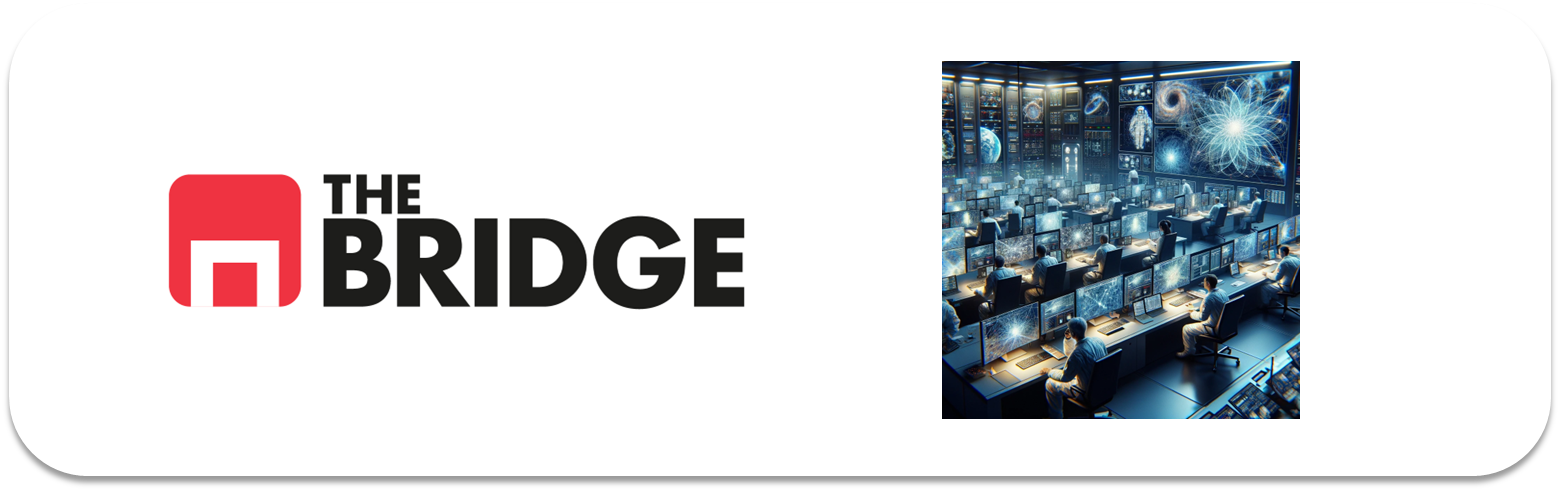

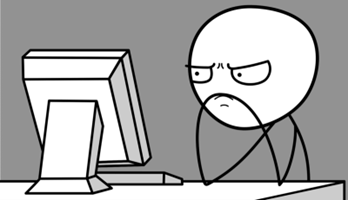

Para ejercitarte y afianzar lo aprendido sobre **Redes Convolucionales**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import os
import cv2

## El problema de "Negocio"
Para este ejercicio vas a crear un clasificador automático de paisajes. Los datos los encontrarás en https://www.kaggle.com/datasets/puneet6060/intel-image-classification?select=seg_test como `seg_train.zip` y `seg_test.zip` (o bien en el botón de download).  

NOTA: Son archivos bastante grandes (386MB en total). Por supuesto, no es necesario que tengas que mantenerlos en tu ordenador una vez realizado el ejercicio, bórralos si es el caso.




### Ejercicio 1

Cargar las imágenes. Mira cómo están almacenados los datos. Tendrás que recorrer las carpetas, cargar las imágenes en memoria y etiquetarlas con los nombres de las carpetas. Realiza un reshape de cada imagen (comienza el ejercicio con 32x32, para ir más rápido en las ejecuciones). Para ello:

1. Descarga las imagenes del repositorio de Kaggle en el directorio que vayas a emplear para el ejercicio.
2. Descomprime los datos (son ficheros de imágenes) de forma que tengas dos subdirectorios seg_train y seg_test en el que estén ya colgando directamente los directorios de cada clase de paisajes. Si descargaste seg_pred, puedes eliminarlo.
3. Crea unas variables como las siguientes (ajustándolas a tu caso/rutas particulares):

```python
ROOT_PATH = './data/'
TRAIN_PATH = ROOT_PATH + "seg_train/"
TEST_PATH = ROOT_PATH + "seg_test/"
```
4. Utiliza la siguiente función para crear los X_train, y_train y X_test e y_test:

```python
def read_data(directorio, reshape_dim = (32,32)):
    X = []
    y = []
    for folder in os.listdir(directorio):
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):

                image = imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim) # Redimensionamos las imágenes a 32x32

                X.append(image)
                y.append(folder)

    return np.array(X),np.array(y)
```


*Pues copiamos lo que nos dicen y lo aplicamos a los dos directorios para tener las X y las y*

In [2]:
ROOT_PATH = './data/'
TRAIN_PATH = ROOT_PATH + "seg_train/seg_train/"
TEST_PATH = ROOT_PATH + "seg_test/seg_test/"

In [3]:

# --- Función de carga ---
def read_data(directorio, reshape_dim=(32, 32)):
    X = []
    y = []
    for folder in os.listdir(directorio):
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):
                image = imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim)  # Redimensionamos las imágenes a 32x32
                X.append(image)
                y.append(folder)
    return np.array(X), np.array(y)

# --- Carga de train y test ---
X_train, y_train = read_data(TRAIN_PATH, reshape_dim=(32, 32))
X_test, y_test = read_data(TEST_PATH, reshape_dim=(32, 32))

### Ejercicio 2

Haz la visualización del dataset: comprueba cuantos datos tienes, que forma, investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.


In [4]:
# --- Tamaño y forma de los datos ---
print("=== Forma de los datos ===")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

=== Forma de los datos ===
X_train: (14034, 32, 32, 3)
y_train: (14034,)
X_test: (3000, 32, 32, 3)
y_test: (3000,)


In [5]:
print("\nNúmero de imágenes en train:", X_train.shape[0])
print("Número de imágenes en test:", X_test.shape[0])
print("Dimensiones de cada imagen (alto, ancho, canales):", X_train.shape[1:])


Número de imágenes en train: 14034
Número de imágenes en test: 3000
Dimensiones de cada imagen (alto, ancho, canales): (32, 32, 3)


In [6]:
# --- Tipos de datos ---
print("\n=== Tipos de datos ===")
print("dtype de X_train:", X_train.dtype)
print("dtype de y_train:", y_train.dtype)


=== Tipos de datos ===
dtype de X_train: uint8
dtype de y_train: <U9


In [7]:
# --- Rango de valores de píxeles ---
print("\n=== Rango de valores de píxeles ===")
print("Min:", X_train.min(), "Max:", X_train.max())
print("Media:", X_train.mean(), "Desviación estándar:", X_train.std())


=== Rango de valores de píxeles ===
Min: 0 Max: 255
Media: 113.9272575289624 Desviación estándar: 68.93926454348038


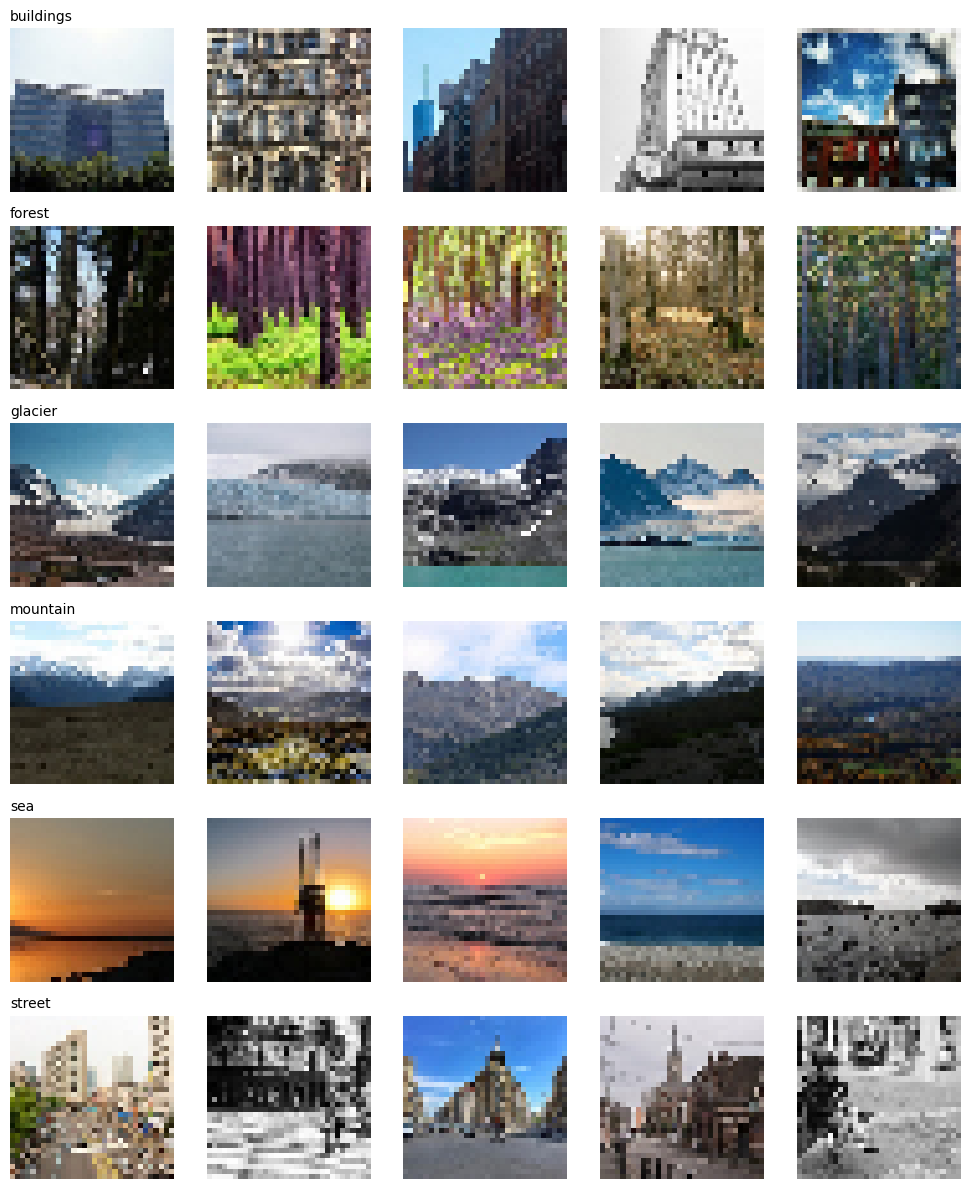


Formas únicas encontradas en X_train: {(32, 32, 3)}


In [8]:
# --- Comprobación visual: muestras aleatorias de cada clase ---
def plot_random_samples(X, y, n_por_clase=5, seed=42):
    rng = np.random.default_rng(seed)
    clases = np.unique(y)
    fig, axes = plt.subplots(len(clases), n_por_clase,
                              figsize=(n_por_clase * 2, len(clases) * 2))
    for i, clase in enumerate(clases):
        idx_clase = np.where(y == clase)[0]
        idx_muestra = rng.choice(idx_clase, size=n_por_clase, replace=False)
        for j, idx in enumerate(idx_muestra):
            ax = axes[i, j]
            ax.imshow(X[idx])
            ax.axis("off")
            if j == 0:
                ax.set_title(clase, loc="left", fontsize=10)
    plt.tight_layout()
    plt.show()

plot_random_samples(X_train, y_train, n_por_clase=5)

# --- Comprobación de que no hay imágenes con formas distintas o corruptas ---
formas_unicas = set(img.shape for img in X_train)
print("\nFormas únicas encontradas en X_train:", formas_unicas)

### Ejercicio 3

Ahora haz un pequeño miniEda y normaliza las features



=== Resumen general ===
Imágenes en train: 14034
Imágenes en test:  3000
Dimensiones por imagen: (32, 32, 3)
Número de clases: 6
Clases: [np.str_('buildings'), np.str_('forest'), np.str_('glacier'), np.str_('mountain'), np.str_('sea'), np.str_('street')]

=== Estadísticos de píxeles (train, sin normalizar) ===
Min: 0  Max: 255
Media: 113.93  Desv. estándar: 68.94

=== Estadísticos por canal (train) ===
  Canal R -> media: 109.60, std: 66.31
  Canal G -> media: 116.56, std: 65.93
  Canal B -> media: 115.63, std: 74.06

=== Distribución de clases ===
       clase  train  train_%  test  test_%
0  buildings   2191    15.61   437   14.57
1     forest   2271    16.18   474   15.80
2    glacier   2404    17.13   553   18.43
3   mountain   2512    17.90   525   17.50
4        sea   2274    16.20   510   17.00
5     street   2382    16.97   501   16.70


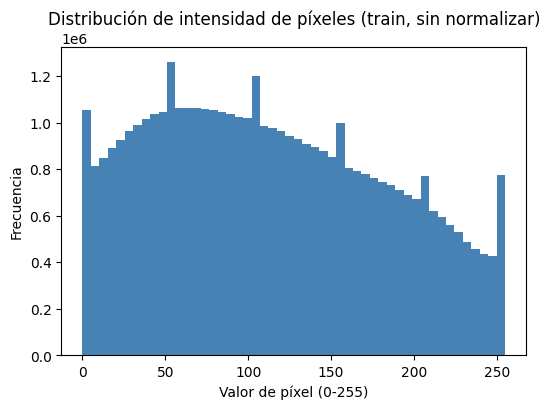

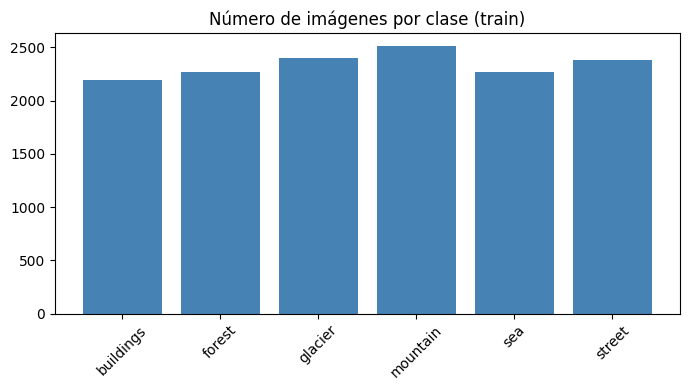

In [9]:

# ============================================================
# Mini-EDA
# ============================================================

# --- Resumen general ---
print("=== Resumen general ===")
print(f"Imágenes en train: {X_train.shape[0]}")
print(f"Imágenes en test:  {X_test.shape[0]}")
print(f"Dimensiones por imagen: {X_train.shape[1:]}")
print(f"Número de clases: {len(np.unique(y_train))}")
print(f"Clases: {sorted(np.unique(y_train))}")

# --- Estadísticos de los píxeles (antes de normalizar) ---
print("\n=== Estadísticos de píxeles (train, sin normalizar) ===")
print(f"Min: {X_train.min()}  Max: {X_train.max()}")
print(f"Media: {X_train.mean():.2f}  Desv. estándar: {X_train.std():.2f}")

# --- Estadísticos por canal (R, G, B) ---
print("\n=== Estadísticos por canal (train) ===")
for i, canal in enumerate(["R", "G", "B"]):
    print(f"  Canal {canal} -> media: {X_train[:, :, :, i].mean():.2f}, "
          f"std: {X_train[:, :, :, i].std():.2f}")

# --- Distribución de clases (train vs test) ---
clases_train, counts_train = np.unique(y_train, return_counts=True)
clases_test, counts_test = np.unique(y_test, return_counts=True)

df_dist = pd.DataFrame({
    "clase": clases_train,
    "train": counts_train,
    "train_%": (counts_train / len(y_train) * 100).round(2)
}).merge(
    pd.DataFrame({"clase": clases_test, "test": counts_test,
                  "test_%": (counts_test / len(y_test) * 100).round(2)}),
    on="clase"
)
print("\n=== Distribución de clases ===")
print(df_dist)

# --- Histograma de intensidad de píxeles ---
plt.figure(figsize=(6, 4))
plt.hist(X_train.ravel(), bins=50, color="steelblue")
plt.title("Distribución de intensidad de píxeles (train, sin normalizar)")
plt.xlabel("Valor de píxel (0-255)")
plt.ylabel("Frecuencia")
plt.show()

# --- Balance de clases (gráfico) ---
plt.figure(figsize=(7, 4))
plt.bar(df_dist["clase"], df_dist["train"], color="steelblue")
plt.title("Número de imágenes por clase (train)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




=== Tras la normalización ===
dtype: float32
Min: 0.0  Max: 1.0
Media: 0.4468  Desv. estándar: 0.2703


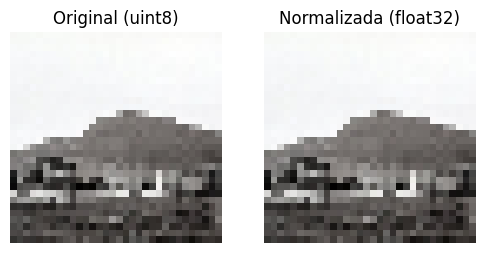

In [10]:
# ============================================================
# Normalización de features
# ============================================================

# Los píxeles están en uint8 (0-255). Escalamos a [0, 1] en float32
# (float32 en vez de float64 para ahorrar memoria, algo relevante con datasets de imágenes)
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

print("\n=== Tras la normalización ===")
print(f"dtype: {X_train_norm.dtype}")
print(f"Min: {X_train_norm.min()}  Max: {X_train_norm.max()}")
print(f"Media: {X_train_norm.mean():.4f}  Desv. estándar: {X_train_norm.std():.4f}")

# --- Comprobación visual de que la normalización no altera las imágenes ---
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(X_train[0])
axes[0].set_title("Original (uint8)")
axes[0].axis("off")
axes[1].imshow(X_train_norm[0])
axes[1].set_title("Normalizada (float32)")
axes[1].axis("off")
plt.show()

### Ejercicio 4

Diseña la arquitectura de la red. Recuerda que es un algiritmo de clasificación. Ojo con las dimensiones de la entrada. Como guía, copia o parte de la arquitectura del workout (un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer)


In [11]:
import numpy as np
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPool2D, Dropout, Flatten, Dense
from keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder

In [12]:
# ============================================================
# Codificación de etiquetas (necesario antes de entrenar)
# ============================================================
# y_train/y_test son strings ('buildings', 'forest', ...) -> los pasamos a enteros
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Clases:", le.classes_)
print("Ejemplo:", y_train[0], "->", y_train_enc[0])

num_classes = len(le.classes_)
input_shape = X_train_norm.shape[1:]  # (32, 32, 3)
print("Input shape:", input_shape)
print("Número de clases:", num_classes)

Clases: ['buildings' 'forest' 'glacier' 'mountain' 'sea' 'street']
Ejemplo: buildings -> 0
Input shape: (32, 32, 3)
Número de clases: 6


In [13]:
# ============================================================
# Arquitectura de la CNN
# ============================================================
model = Sequential()

# --- Capa de entrada ---
model.add(Input(shape=input_shape)) # (32, 32, 3)

# --- Bloque Convolucional 1 ---
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='Same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))
# Resolución tras este bloque: 32/2 = 16 -> (16, 16, 32)

# --- Bloque Convolucional 2 ---
model.add(Conv2D(filters=64, kernel_size=(3,3), padding='Same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))
# Resolución tras este bloque: 16/2 = 8 -> (8, 8, 64)

# --- Fully connected ---
model.add(Flatten()) # 8*8*64 = 4096 features
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax')) # 6 clases -> salida softmax

### Ejercicio 5

Escoge el resto de hiperparámetros (optimizador, learning_rate, función de pérdida, métrica,...) y compila el modelo. Muestra un resumen del mismo

In [14]:
# ============================================================
# Compilación
# ============================================================

optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

model.compile(optimizer=optimizer,
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,069,766 (4.08 MB)

 Trainable params: 1,069,766 (4.08 MB)

 Non-trainable params: 0 (0.00 B)

### Ejercicio 6

Entrena el modelo reservando un 20% de los datos del entrenamiento para validar y con los callbacks que creas necesarios. NOTA: Ojo, tendrás que preparar un poco los X,y antes.



In [17]:
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

# Separamos un conjunto de validación estratificado y barajado
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_norm, y_train_enc,
    test_size=0.2,
    stratify=y_train_enc,
    random_state=42
)

print("X_tr:", X_tr.shape, " X_val:", X_val.shape)
print("Distribución y_tr:", np.unique(y_tr, return_counts=True))
print("Distribución y_val:", np.unique(y_val, return_counts=True))



X_tr: (11227, 32, 32, 3)  X_val: (2807, 32, 32, 3)
Distribución y_tr: (array([0, 1, 2, 3, 4, 5]), array([1753, 1817, 1923, 2009, 1819, 1906]))
Distribución y_val: (array([0, 1, 2, 3, 4, 5]), array([438, 454, 481, 503, 455, 476]))


In [18]:
# ============================================================
# Callbacks
# ============================================================
early_stopping = EarlyStopping(         # Si el modelo durante 5 epocas no mejora el 'val_loss' se detiene y se queda con el mejor resultado
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(           # Guarda en disco el mejor modelo segú 'val_accuracy', para tener la opción de recuperarlo más tarde sin tener que reentrenar
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(          # reduce el 'learnin_rate' a la mitad si el 'val_loss' se estanca durante 3 epocas.
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

# ============================================================
# Entrenamiento
# ============================================================
batch_size= 128
epochs = 100        # con EarlyStopping podemos permitirnos poner más épocas de las que probablemente se usarán
validation_split=0.2

history = model.fit(
    X_tr, y_tr,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=validation_split,
    callbacks=[early_stopping, checkpoint, reduce_lr]
)

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.5450 - loss: 1.2082 - val_accuracy: 0.6407 - val_loss: 1.0074 - learning_rate: 5.0000e-04
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.6355 - loss: 0.9734 - val_accuracy: 0.6785 - val_loss: 0.8899 - learning_rate: 5.0000e-04
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.6589 - loss: 0.9076 - val_accuracy: 0.7039 - val_loss: 0.8518 - learning_rate: 5.0000e-04
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.6809 - loss: 0.8621 - val_accuracy: 0.7195 - val_loss: 0.8118 - learning_rate: 5.0000e-04
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.6903 - loss: 0.8352 - val_accuracy: 0.7155 - val_loss: 0.8128 - learning_rate: 5.0000e-04
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.7054 - loss: 0.7912 - val_accuracy: 0.7191 - val_loss: 0.7967 - learning_rate: 5.0000e-04
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 


### Ejercicio 7

Representa el objeto history y comenta la evolución de tu entrenamiento.



In [19]:
# --- Convertir el history a DataFrame para explorarlo cómodamente ---
history_df = pd.DataFrame(history.history)
print(history_df)

    accuracy      loss  val_accuracy  val_loss  learning_rate
0   0.545040  1.208218      0.640695  1.007422       0.000500
1   0.635453  0.973368      0.678540  0.889911       0.000500
2   0.658947  0.907637      0.703918  0.851823       0.000500
3   0.680882  0.862123      0.719501  0.811823       0.000500
4   0.690346  0.835178      0.715494  0.812784       0.000500
5   0.705378  0.791246      0.719056  0.796662       0.000500
6   0.718851  0.765824      0.723508  0.761767       0.000500
7   0.725532  0.755089      0.738201  0.727562       0.000500
8   0.734662  0.724028      0.740427  0.713583       0.000500
9   0.747690  0.698650      0.754230  0.691546       0.000500
10  0.751698  0.680560      0.751113  0.694527       0.000500
11  0.761496  0.660989      0.766696  0.675406       0.000500
12  0.769179  0.632906      0.763134  0.671141       0.000500
13  0.772408  0.633583      0.772930  0.649004       0.000500
14  0.787329  0.600122      0.774265  0.629009       0.000500
15  0.78

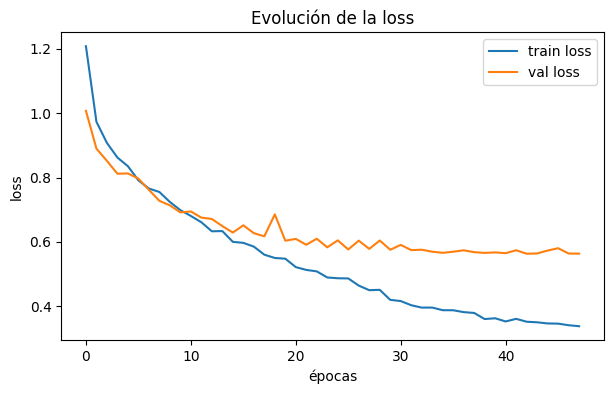

In [20]:
# --- Curvas de loss ---
plt.figure(figsize=(7, 4))
plt.plot(history_df["loss"], label="train loss")
plt.plot(history_df["val_loss"], label="val loss")
plt.title("Evolución de la loss")
plt.xlabel("épocas")
plt.ylabel("loss")
plt.legend()
plt.show()

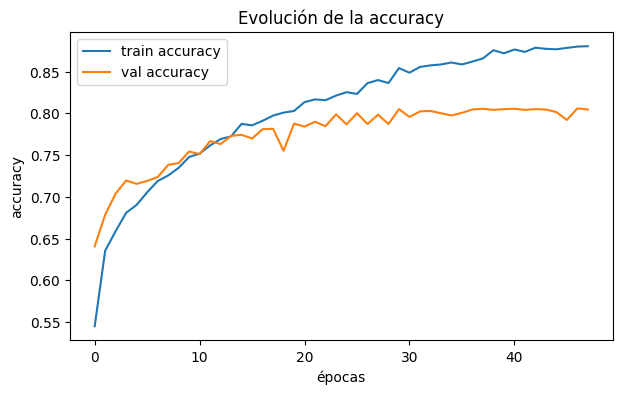

In [21]:
# --- Curvas de accuracy ---
plt.figure(figsize=(7, 4))
plt.plot(history_df["accuracy"], label="train accuracy")
plt.plot(history_df["val_accuracy"], label="val accuracy")
plt.title("Evolución de la accuracy")
plt.xlabel("épocas")
plt.ylabel("accuracy")
plt.legend()
plt.show()

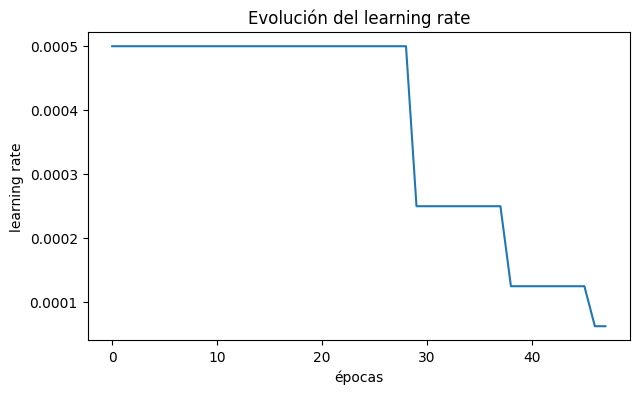

In [22]:
# --- Evolución del learning rate (si ReduceLROnPlateau actuó) ---
if "learning_rate" in history_df.columns:
    plt.figure(figsize=(7, 4))
    plt.plot(history_df["learning_rate"])
    plt.title("Evolución del learning rate")
    plt.xlabel("épocas")
    plt.ylabel("learning rate")
    plt.show()


In [23]:
# --- Resumen numérico ---
print(f"\nÉpocas entrenadas: {len(history_df)}")
print(f"Mejor val_accuracy: {history_df['val_accuracy'].max():.4f} "
      f"(época {history_df['val_accuracy'].idxmax() + 1})")
print(f"Mejor val_loss: {history_df['val_loss'].min():.4f} "
      f"(época {history_df['val_loss'].idxmin() + 1})")
print(f"Accuracy final en train: {history_df['accuracy'].iloc[-1]:.4f}")
print(f"Accuracy final en validación: {history_df['val_accuracy'].iloc[-1]:.4f}")


Épocas entrenadas: 48
Mejor val_accuracy: 0.8059 (época 47)
Mejor val_loss: 0.5631 (época 43)
Accuracy final en train: 0.8803
Accuracy final en validación: 0.8045



### Ejercicio 8

Evalua el modelo con los datos de test, además muestra el report de clasificación y la matriz de confusión.



X_test_norm: (3000, 32, 32, 3) float32
y_test_enc: (3000,) int64
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8087 - loss: 0.5588

Test loss: 0.5588
Test accuracy: 0.8087
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

=== Classification report ===
              precision    recall  f1-score   support

   buildings       0.80      0.71      0.75       437
      forest       0.91      0.94      0.92       474
     glacier       0.79      0.76      0.78       553
    mountain       0.75      0.80      0.77       525
         sea       0.80      0.79      0.80       510
      street       0.82      0.85      0.83       501

    accuracy                           0.81      3000
   macro avg       0.81      0.81      0.81      3000
weighted avg       0.81      0.81      0.81      3000



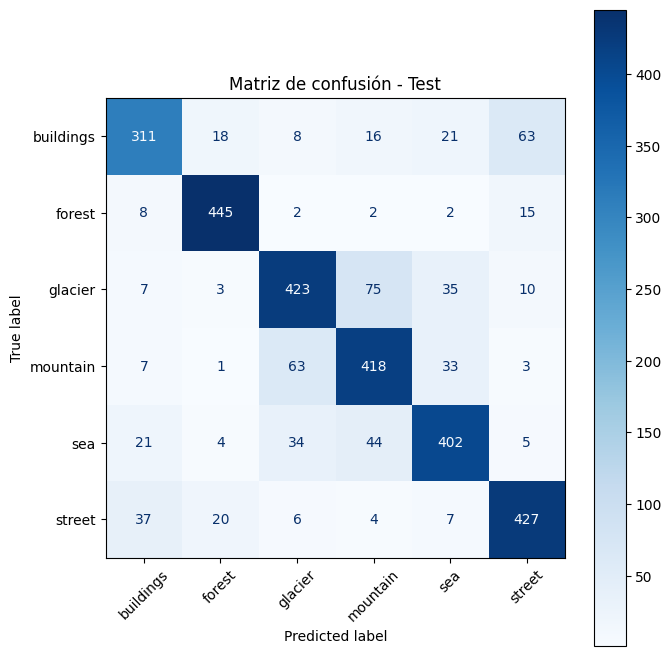

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ============================================================
# Preparación del test (mismo tratamiento que el train)
# ============================================================
# X_test_norm ya está normalizado (float32, [0,1]) del Ejercicio 3
# y_test_enc ya está codificado con el mismo LabelEncoder del Ejercicio 4 (le.transform(y_test))

print("X_test_norm:", X_test_norm.shape, X_test_norm.dtype)
print("y_test_enc:", y_test_enc.shape, y_test_enc.dtype)

# ============================================================
# Evaluación global
# ============================================================
test_loss, test_accuracy = model.evaluate(X_test_norm, y_test_enc)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

# ============================================================
# Predicciones
# ============================================================
y_pred_probs = model.predict(X_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

# ============================================================
# Classification report
# ============================================================
print("\n=== Classification report ===")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

# ============================================================
# Matriz de confusión
# ============================================================
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test_enc, y_pred,
    display_labels=le.classes_,
    xticks_rotation=45,
    ax=ax,
    cmap="Blues"
)
plt.title("Matriz de confusión - Test")
plt.tight_layout()
plt.show()


### Ejercicio 9 

Representa algunos de los paisajes donde el modelo comete errores y muestra la confianza que tenía en ellos.





Número total de errores: 574 de 3000 (19.13%)

=== Errores con MAYOR confianza (el modelo estaba muy seguro y falló) ===


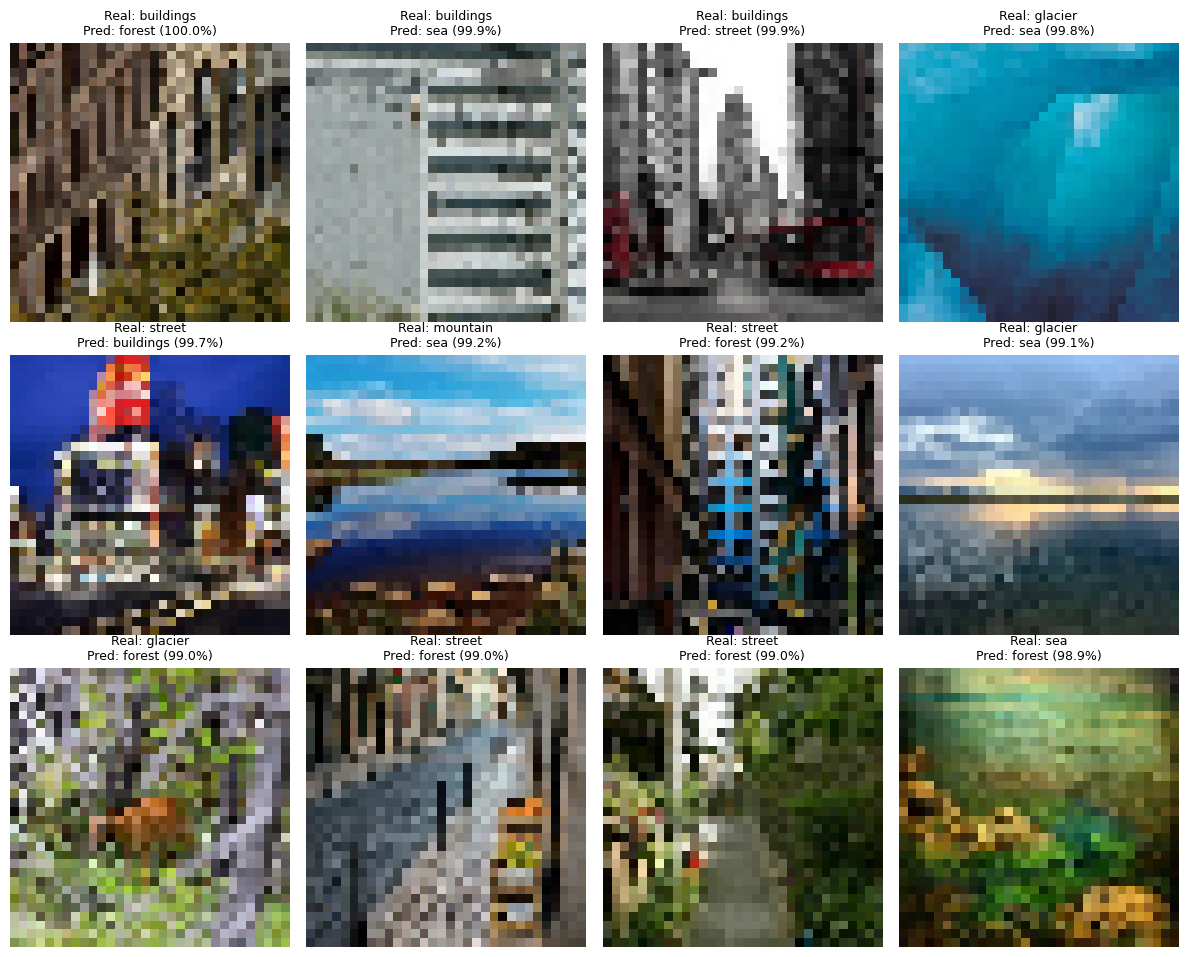


=== Errores con MENOR confianza (el modelo dudaba) ===


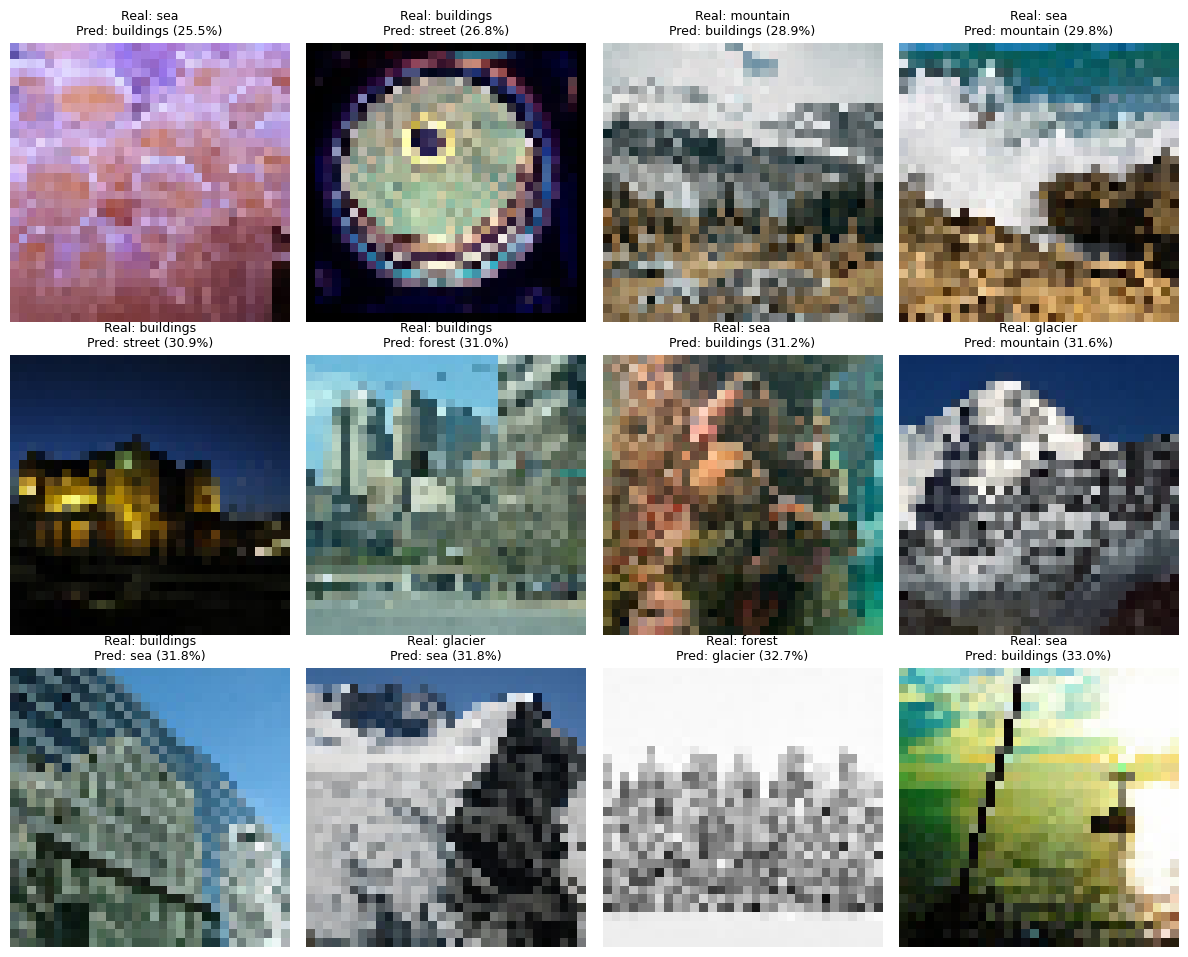


Confianza media en ACIERTOS: 0.8667
Confianza media en ERRORES:  0.6707


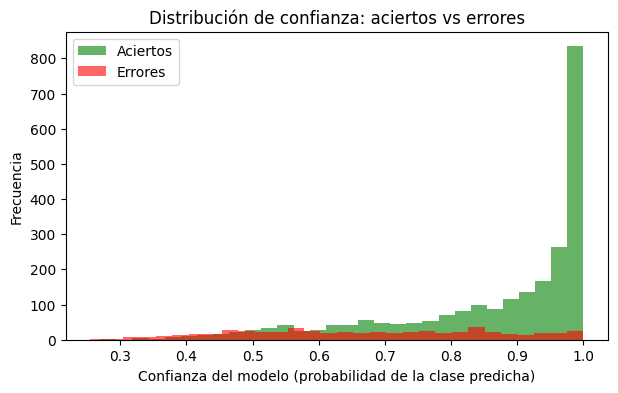

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Identificar los errores de clasificación
# ============================================================
errores_idx = np.where(y_pred != y_test_enc)[0]
print(f"Número total de errores: {len(errores_idx)} de {len(y_test_enc)} "
      f"({len(errores_idx) / len(y_test_enc) * 100:.2f}%)")

# Confianza del modelo en cada predicción (probabilidad de la clase predicha)
confianza_pred = y_pred_probs[np.arange(len(y_pred)), y_pred]

# ============================================================
# Función para mostrar errores con la confianza del modelo
# ============================================================
def plot_errores(indices, n=12, ordenar_por_confianza=None):
    """
    ordenar_por_confianza:
        None -> orden original
        'desc' -> errores donde el modelo estaba MÁS seguro (más "graves")
        'asc'  -> errores donde el modelo estaba MENOS seguro (más "dudosos")
    """
    idx = indices.copy()
    if ordenar_por_confianza == "desc":
        idx = idx[np.argsort(-confianza_pred[idx])]
    elif ordenar_por_confianza == "asc":
        idx = idx[np.argsort(confianza_pred[idx])]

    idx = idx[:n]
    n_cols = 4
    n_rows = int(np.ceil(n / n_cols))
    plt.figure(figsize=(n_cols * 3, n_rows * 3.2))

    for i, ix in enumerate(idx):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(X_test_norm[ix])
        plt.axis("off")
        real = le.classes_[y_test_enc[ix]]
        predicha = le.classes_[y_pred[ix]]
        conf = confianza_pred[ix]
        plt.title(f"Real: {real}\nPred: {predicha} ({conf:.1%})", fontsize=9)

    plt.tight_layout()
    plt.show()

# --- Errores más "graves": el modelo estaba muy seguro y aun así falló ---
print("\n=== Errores con MAYOR confianza (el modelo estaba muy seguro y falló) ===")
plot_errores(errores_idx, n=12, ordenar_por_confianza="desc")

# --- Errores más "dudosos": el modelo apenas tenía confianza ---
print("\n=== Errores con MENOR confianza (el modelo dudaba) ===")
plot_errores(errores_idx, n=12, ordenar_por_confianza="asc")

# ============================================================
# Estadística general de confianza en aciertos vs errores
# ============================================================
aciertos_idx = np.where(y_pred == y_test_enc)[0]

print(f"\nConfianza media en ACIERTOS: {confianza_pred[aciertos_idx].mean():.4f}")
print(f"Confianza media en ERRORES:  {confianza_pred[errores_idx].mean():.4f}")

plt.figure(figsize=(7, 4))
plt.hist(confianza_pred[aciertos_idx], bins=30, alpha=0.6, label="Aciertos", color="green")
plt.hist(confianza_pred[errores_idx], bins=30, alpha=0.6, label="Errores", color="red")
plt.xlabel("Confianza del modelo (probabilidad de la clase predicha)")
plt.ylabel("Frecuencia")
plt.title("Distribución de confianza: aciertos vs errores")
plt.legend()
plt.show()

### Ejercicio EXTRA: 

Aumenta la resolución y repite el ejercicio con la misma topología de red

X_train: (14034, 64, 64, 3)  X_test: (3000, 64, 64, 3)
Input shape: (64, 64, 3)  Clases: ['buildings' 'forest' 'glacier' 'mountain' 'sea' 'street']


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,215,494 (16.08 MB)

 Trainable params: 4,215,494 (16.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 16s 172ms/step - accuracy: 0.5049 - loss: 1.2810 - val_accuracy: 0.6309 - val_loss: 1.0198 - learning_rate: 0.0010
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 15s 168ms/step - accuracy: 0.6460 - loss: 0.9442 - val_accuracy: 0.6758 - val_loss: 0.8478 - learning_rate: 0.0010
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 15s 165ms/step - accuracy: 0.6982 - loss: 0.8241 - val_accuracy: 0.7371 - val_loss: 0.7678 - learning_rate: 0.0010
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 164ms/step - accuracy: 0.7382 - loss: 0.7317 - val_accuracy: 0.7624 - val_loss: 0.6820 - learning_rate: 0.0010
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 147ms/step - accuracy: 0.7607 - loss: 0.6664 - val_accuracy: 0.7699 - val_loss: 0.6532 - learning_rate: 0.0010
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step - accuracy: 0.7865 - loss: 0.6017 - val_accuracy: 0.7684 - val_loss: 0.6637 - learning_rate: 0.0010
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 149ms/step - accuracy: 0.8023 - l

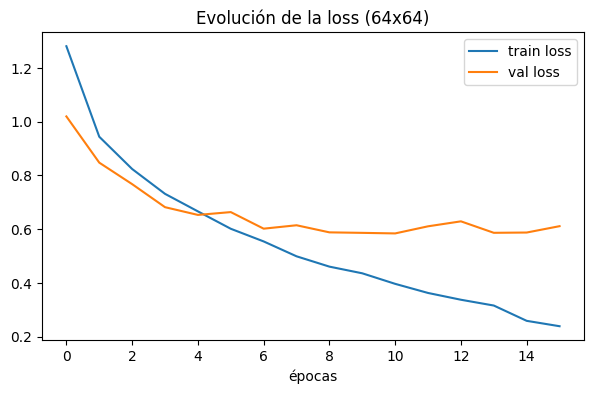

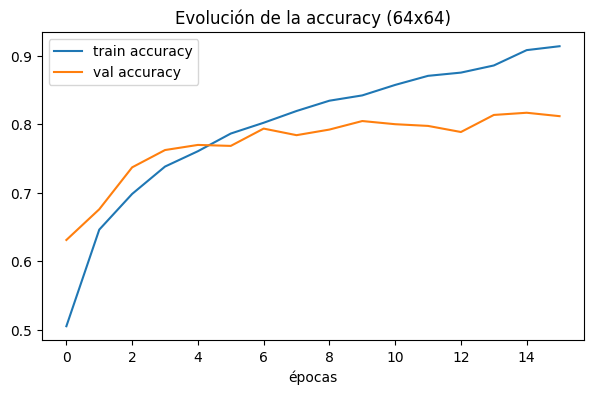

Mejor val_accuracy: 0.8169
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7997 - loss: 0.5826

Test loss: 0.5826  Test accuracy: 0.7997
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

=== Classification report (64x64) ===
              precision    recall  f1-score   support

   buildings       0.81      0.71      0.76       437
      forest       0.90      0.96      0.93       474
     glacier       0.76      0.76      0.76       553
    mountain       0.71      0.83      0.76       525
         sea       0.80      0.75      0.77       510
      street       0.86      0.79      0.82       501

    accuracy                           0.80      3000
   macro avg       0.80      0.80      0.80      3000
weighted avg       0.80      0.80      0.80      3000



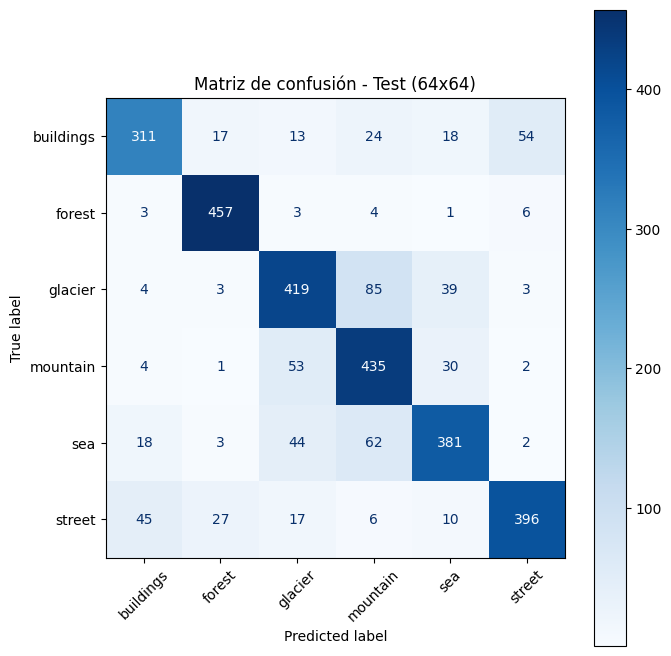

In [27]:
import os
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ============================================================
# 1) Carga de datos con mayor resolución (64x64 en vez de 32x32)
# ============================================================
ROOT_PATH = './data/'
TRAIN_PATH = ROOT_PATH + "seg_train/seg_train/"   # ajusta según tu estructura real
TEST_PATH = ROOT_PATH + "seg_test/seg_test/"

def read_data(directorio, reshape_dim=(64, 64)):
    X = []
    y = []
    for folder in os.listdir(directorio):
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):
                image = imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim)
                X.append(image)
                y.append(folder)
    return np.array(X), np.array(y)

X_train, y_train = read_data(TRAIN_PATH, reshape_dim=(64, 64))
X_test, y_test = read_data(TEST_PATH, reshape_dim=(64, 64))

print("X_train:", X_train.shape, " X_test:", X_test.shape)

# ============================================================
# 2) Normalización
# ============================================================
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

# ============================================================
# 3) Codificación de etiquetas
# ============================================================
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
num_classes = len(le.classes_)
input_shape = X_train_norm.shape[1:]  # (64, 64, 3)
print("Input shape:", input_shape, " Clases:", le.classes_)

# ============================================================
# 4) Split train/val estratificado (mismo criterio que el Ejercicio 6)
# ============================================================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_norm, y_train_enc,
    test_size=0.2,
    stratify=y_train_enc,
    random_state=42
)

# ============================================================
# 5) Misma topología de red que antes (solo cambia el input_shape,
#    que se ajusta solo; el resto de capas no se toca)
# ============================================================
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(3, 3), padding='Same',
                  activation='relu', input_shape=input_shape))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='Same', activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(256, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation="softmax"))

optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

# ============================================================
# 6) Callbacks y entrenamiento
# ============================================================
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_model_64x64.keras", monitor="val_accuracy", save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)

history = model.fit(
    X_tr, y_tr,
    batch_size=128,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, checkpoint, reduce_lr]
)

# ============================================================
# 7) Curvas de entrenamiento
# ============================================================
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(7, 4))
plt.plot(history_df["loss"], label="train loss")
plt.plot(history_df["val_loss"], label="val loss")
plt.title("Evolución de la loss (64x64)")
plt.xlabel("épocas"); plt.legend(); plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df["accuracy"], label="train accuracy")
plt.plot(history_df["val_accuracy"], label="val accuracy")
plt.title("Evolución de la accuracy (64x64)")
plt.xlabel("épocas"); plt.legend(); plt.show()

print(f"Mejor val_accuracy: {history_df['val_accuracy'].max():.4f}")

# ============================================================
# 8) Evaluación en test
# ============================================================
test_loss, test_accuracy = model.evaluate(X_test_norm, y_test_enc)
print(f"\nTest loss: {test_loss:.4f}  Test accuracy: {test_accuracy:.4f}")

y_pred_probs = model.predict(X_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n=== Classification report (64x64) ===")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test_enc, y_pred, display_labels=le.classes_,
    xticks_rotation=45, ax=ax, cmap="Blues"
)
plt.title("Matriz de confusión - Test (64x64)")
plt.tight_layout()
plt.show()